# Gradient Boosting Regressor (GBR)

**Grid Search over hyperparameters**

Author: Pete King

We test the performance of an ensemble decision tree based on the concept of gradient boosting, where many weak learners are combined to provide predictions that are less likely to overfit to training data.  Compared to time series methods like ARIMA and the LSTM deep-learning model, the GBR estimator assumes no relationship between observations at different timestamps -- a disadvantage when forecasting time-series data.  However, the GBR retains an advantage over a linear model like ElasticNet because it can deal with non-linear relationships in the data.

In this project, we examine how well such a model can predict future volatility for an ETF over a moderate horizon, given a feature vector of market, macroeconomic, and other financial variables.  Specifically, each observation is a feature vector (**x_t**) that contains the daily return for the ETF, its near-term historic volatility, and other features at time **t** (a daily observation).  The label (**y_t**) is the mid-term future volatility, which we computed earlier using a rolling window.

Unlike other classic machine learning estimators, the GBR estimator works as a decision tree and does not require us to standardize our input features.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_f-vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = GradientBoostingRegressor(loss='squared_error', warm_start=False)
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 5],
    'max_features': ['sqrt', None]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MSE',
    cv=ts_cv
)

In [5]:
reg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', None], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MSE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl.

### Visualize performance; Check evaluation metrics

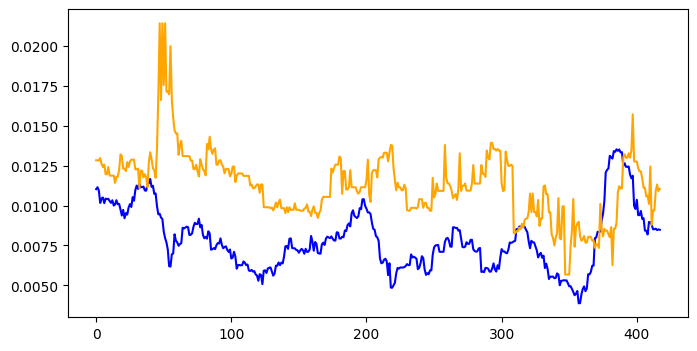

In [6]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [7]:
print(f'MSE: {mean_squared_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MSE: 1.8102491088321762e-05
R2: -3.761701958620246


From the plot we see that the model tends to follow the general future volatility trend fairly well (with some notable exceptions), but also consistently overestimates future volatility.  Overestimation is not such a bad thing considering the business case: we want to ensure that an asset does not exceed an investor's risk tolerance.  However, we also want to maximize an investor's return, which makes overestimation of volatility less than ideal.

The negative value for R-squared would seem to indicate that our model explains very little about the actual underlying process, but since we are using multiple input features, we take this value with a grain of salt.  The visualization clearly shows that our model responds to actual asset volatility, albeit often in a delayed manner.

## III. Inspect model

In part we chose a decision tree based model because the implementations in scikit-learn give us an easy way to understand which features are most important in its decision-making process.  Up to this point we are not sure which of the various macroeconomic data and market indicies contribute significantly to accurate predictions.  Let's take a look and see which features have been most important for our best-performing GBR.

In [8]:
feature_importances = list(
    zip(best.feature_names_in_, best.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

real_GDP_chg: 0.163
producer_price_index_chg: 0.148
^MOVE: 0.098
nominal_GDP_chg: 0.084
^VIX: 0.039
SPY_h-vol: 0.031
personal_consumption_expenditure_chg: 0.030
core_PCE_chg: 0.030
XLI_h-vol: 0.026
QQQ_h-vol: 0.024
^VXN: 0.023
XLP_h-vol: 0.023
^GSPC_h-vol: 0.022
average_duration_of_unemployment_chg: 0.022
three_month_yield_diff: 0.022
debt_interest_chg: 0.020
HG=F_h-vol: 0.020
BND_h-vol: 0.017
core_PCI_chg: 0.016
XLU_h-vol: 0.016
debt_to_GDP_chg: 0.014
female_unemployment_rate_chg: 0.014
six_month_yield_diff: 0.011
XLE_h-vol: 0.011
one_month_yield_diff: 0.008
TLT_h-vol: 0.008
teenager_unemployment_rate_chg: 0.008
IEF_h-vol: 0.006
SHY_h-vol: 0.006
HYG_h-vol: 0.006
NG=F_h-vol: 0.006
adult_unemployment_rate_chg: 0.004
one_year_yield_diff: 0.003
BIL_h-vol: 0.003
^FTSE_h-vol: 0.003
XLK_h-vol: 0.002
unemployment_rate_chg: 0.002
CL=F_h-vol: 0.002
GC=F_h-vol: 0.002
TIP_h-vol: 0.002
male_unemployment_rate_chg: 0.001
initial_jobless_claims_chg: 0.001
XLRE_h-vol: 0.001
XLF_h-vol: 0.000
continued_